<a href="https://colab.research.google.com/github/VishalK720/vishalcset343/blob/main/lab_2_1037.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI in Healthcare — Lab Assignment 2

**Course:** B.Tech  
**Course Code:** CSET343  
**Course Name:** AI in Healthcare  
**Year:** 4th Year  
**Semester:** VII  

## Objective

Perform data cleaning and enrichment on a clinical Heart Failure dataset containing patient health records and missing-value checks.

## Dataset

Heart Failure Clinical Records Dataset

## Tasks Covered

1. Dataset Acquisition
2. Dataset Loading
3. Dataset Summary
4. Missing Value Visualization
5. Distribution Analysis
6. Missing Value Imputation
7. Outlier Removal
8. Inconsistency Correction
9. Feature Engineering
10. Categorical Encoding
11. Feature Normalization
12. Summary Statistics
13. Cleaning Validation
14. Final Missing Value Check

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Plotting style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Download the Heart Failure Clinical Records Dataset

!wget -q "https://archive.ics.uci.edu/static/public/519/heart+failure+clinical+records.zip" -O heart_failure.zip

# Extract the dataset
!unzip -o -q heart_failure.zip

print("Dataset downloaded and extracted successfully.")

Dataset downloaded and extracted successfully.


In [4]:
# Load the CSV dataset into a Pandas DataFrame

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (299, 13)


In [5]:
# Display first 5 rows

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.000,0,582,0,20,1,265000.000,1.900,130,1,0,4,1
1,55.000,0,7861,0,38,0,263358.030,1.100,136,1,0,6,1
2,65.000,0,146,0,20,0,162000.000,1.300,129,1,1,7,1
3,50.000,1,111,0,20,0,210000.000,1.900,137,1,0,7,1
4,65.000,1,160,1,20,0,327000.000,2.700,116,0,0,8,1


In [6]:
# Dataset summary

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 299
Number of columns: 13

Column names:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            

In [7]:
# Descriptive statistics

df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000,299.000,299.000,299.000,299.000,299.000,299.000,299.000,299.000,299.000,299.000,299.000,299.000
mean,60.834,0.431,581.839,0.418,38.084,0.351,263358.029,1.394,136.625,0.649,0.321,130.261,0.321
std,11.895,0.496,970.288,0.494,11.835,0.478,97804.237,1.035,4.412,0.478,0.468,77.614,0.468
min,40.000,0.000,23.000,0.000,14.000,0.000,25100.000,0.500,113.000,0.000,0.000,4.000,0.000
25%,51.000,0.000,116.500,0.000,30.000,0.000,212500.000,0.900,134.000,0.000,0.000,73.000,0.000
50%,60.000,0.000,250.000,0.000,38.000,0.000,262000.000,1.100,137.000,1.000,0.000,115.000,0.000
75%,70.000,1.000,582.000,1.000,45.000,1.000,303500.000,1.400,140.000,1.000,1.000,203.000,1.000
max,95.000,1.000,7861.000,1.000,80.000,1.000,850000.000,9.400,148.000,1.000,1.000,285.000,1.000


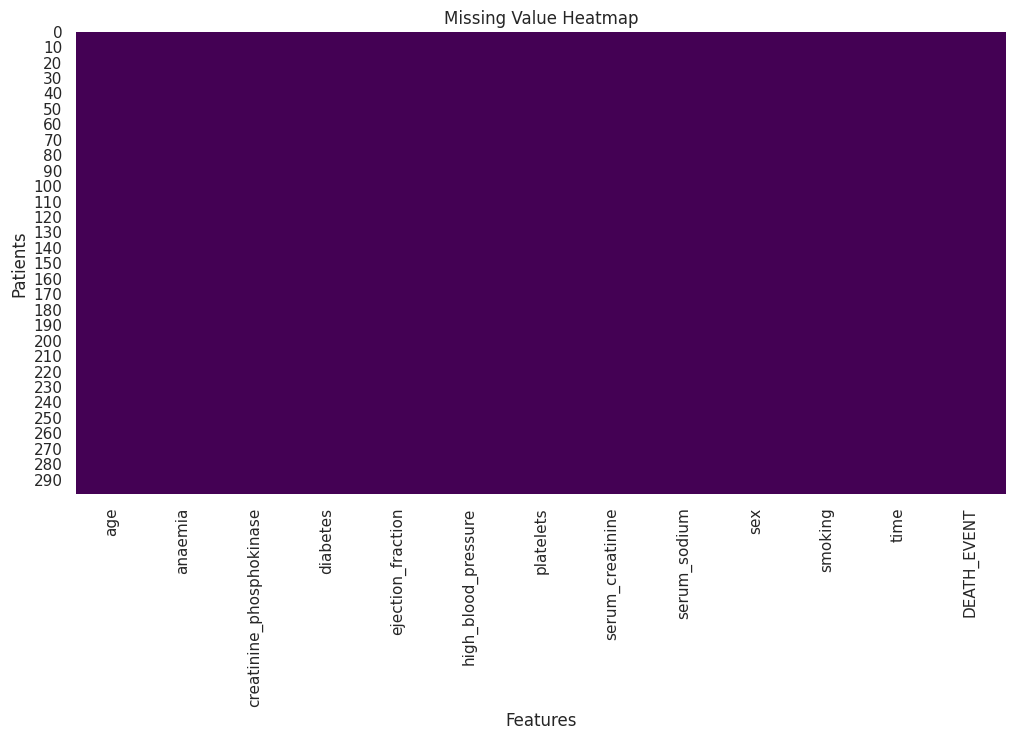

In [8]:
# Visualize missing values

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")
plt.xlabel("Features")
plt.ylabel("Patients")

plt.show()

In [9]:
# Identify numerical columns

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


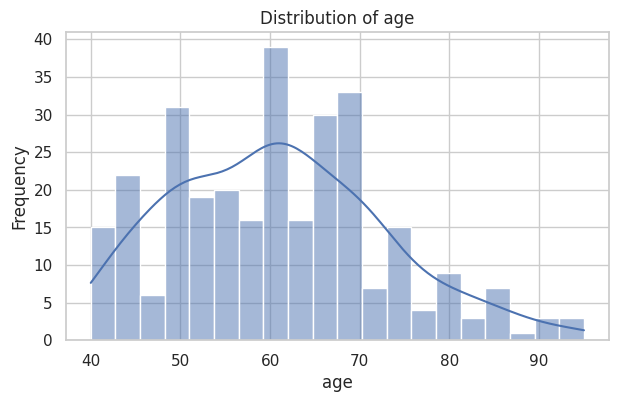

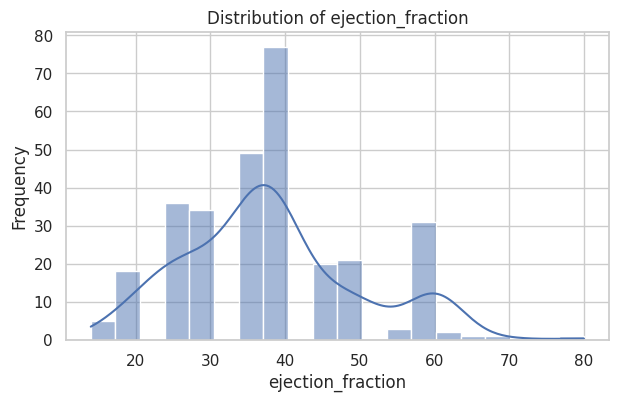

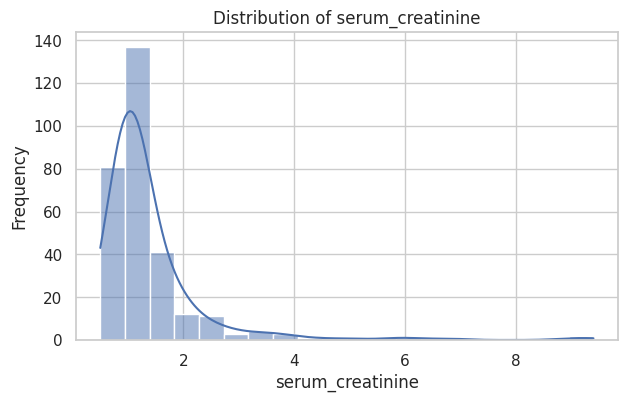

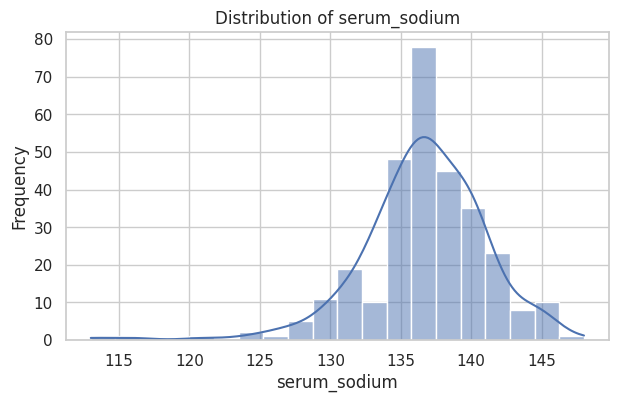

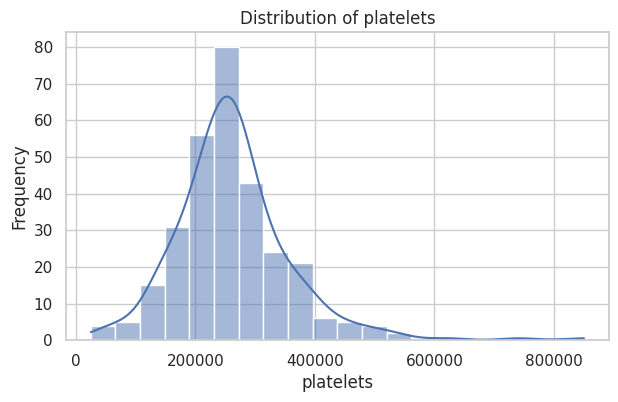

In [10]:
# Plot distributions of selected numerical features

selected_features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "platelets"
]

for feature in selected_features:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[feature],
        kde=True,
        bins=20
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

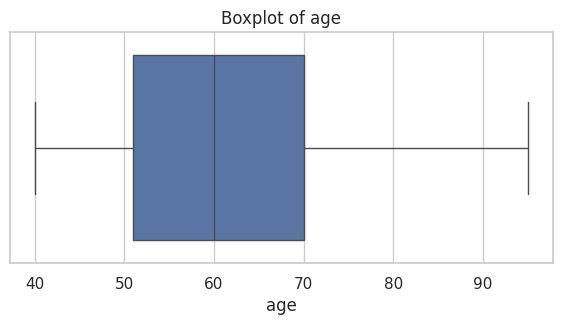

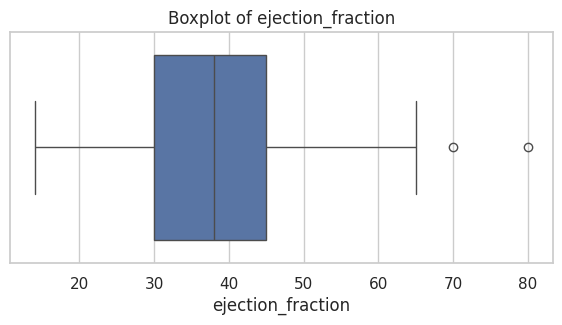

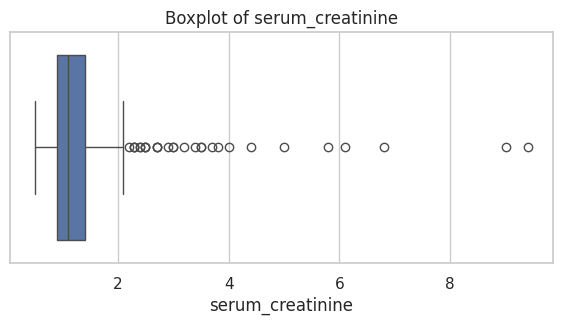

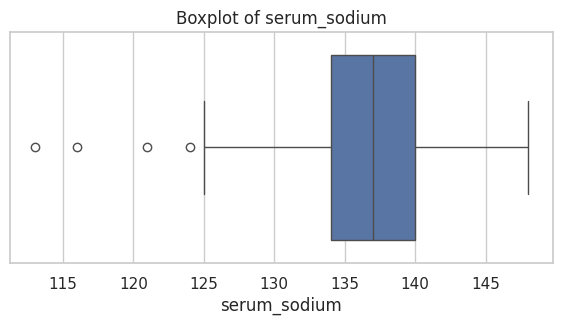

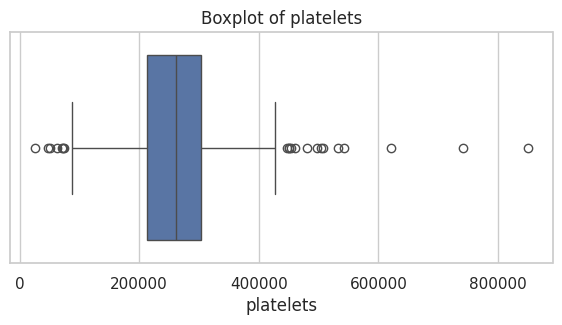

In [11]:
# Boxplots for numerical features

for feature in selected_features:
    plt.figure(figsize=(7, 3))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.show()

In [12]:
# Store summary statistics before cleaning

before_cleaning_stats = df[
    numerical_columns
].agg(
    ["mean", "median", "std"]
).T

print("Summary statistics BEFORE cleaning:")
before_cleaning_stats

Summary statistics BEFORE cleaning:


,mean,median,std
age,60.834,60.000,11.895
anaemia,0.431,0.000,0.496
creatinine_phosphokinase,581.839,250.000,970.288
diabetes,0.418,0.000,0.494
ejection_fraction,38.084,38.000,11.835
high_blood_pressure,0.351,0.000,0.478
platelets,263358.029,262000.000,97804.237
serum_creatinine,1.394,1.100,1.035
serum_sodium,136.625,137.000,4.412
sex,0.649,1.000,0.478


In [13]:
# Create a working copy

df_clean = df.copy()

# Identify numerical and categorical columns

categorical_columns = df_clean.select_dtypes(
    exclude=np.number
).columns.tolist()

numerical_columns = df_clean.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:", numerical_columns)
print("\nCategorical columns:", categorical_columns)

print("\nMissing values before imputation:")
print(df_clean.isnull().sum())

Numerical columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Categorical columns: []

Missing values before imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [14]:
# Impute missing numerical values using median

for column in numerical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

print("Numerical missing-value imputation completed.")

Numerical missing-value imputation completed.


In [15]:
# Impute missing categorical values using mode
# If a categorical feature had missing values, its most frequent value would be used.

for column in categorical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].mode()[0]
        )

print("Categorical missing-value imputation completed.")

Categorical missing-value imputation completed.


In [16]:
# Detect outliers using the IQR method

outlier_summary = {}

for column in numerical_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    )

    outlier_summary[column] = outliers.sum()

outlier_summary = pd.Series(outlier_summary)

print("Number of potential outliers in each numerical feature:")
print(outlier_summary)

Number of potential outliers in each numerical feature:
age                          0
anaemia                      0
creatinine_phosphokinase    29
diabetes                     0
ejection_fraction            2
high_blood_pressure          0
platelets                   21
serum_creatinine            29
serum_sodium                 4
sex                          0
smoking                      0
time                         0
DEATH_EVENT                  0
dtype: int64


In [17]:
# Remove rows containing IQR-based outliers

df_no_outliers = df_clean.copy()

for column in numerical_columns:
    Q1 = df_no_outliers[column].quantile(0.25)
    Q3 = df_no_outliers[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[column] >= lower_bound) &
        (df_no_outliers[column] <= upper_bound)
    ]

print("Original rows:", len(df_clean))
print("Rows after outlier removal:", len(df_no_outliers))
print("Rows removed:", len(df_clean) - len(df_no_outliers))

Original rows: 299
Rows after outlier removal: 224
Rows removed: 75


In [18]:
# Check for invalid age values

negative_age_count = (df_no_outliers["age"] < 0).sum()

print("Negative age values found:", negative_age_count)

# Remove invalid negative ages if present

df_no_outliers = df_no_outliers[
    df_no_outliers["age"] >= 0
].copy()

print("Invalid age values corrected.")

Negative age values found: 0
Invalid age values corrected.


In [19]:
# Check for other clearly invalid clinical values

checks = {
    "Age <= 0": (df_no_outliers["age"] <= 0).sum(),
    "Ejection fraction <= 0": (df_no_outliers["ejection_fraction"] <= 0).sum(),
    "Serum creatinine <= 0": (df_no_outliers["serum_creatinine"] <= 0).sum(),
    "Serum sodium <= 0": (df_no_outliers["serum_sodium"] <= 0).sum(),
    "Platelets <= 0": (df_no_outliers["platelets"] <= 0).sum()
}

print("Clinical consistency checks:")
for check, count in checks.items():
    print(f"{check}: {count}")

Clinical consistency checks:
Age <= 0: 0
Ejection fraction <= 0: 0
Serum creatinine <= 0: 0
Serum sodium <= 0: 0
Platelets <= 0: 0


In [20]:
# Create age_group feature

df_no_outliers["age_group"] = pd.cut(
    df_no_outliers["age"],
    bins=[-np.inf, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"]
)

print(df_no_outliers[
    ["age", "age_group"]
].head(10))

      age age_group
0  75.000       >60
2  65.000       >60
3  50.000     40-60
5  90.000       >60
6  75.000       >60
8  65.000       >60
11 62.000       >60
12 45.000     40-60
13 50.000     40-60
14 49.000     40-60


In [21]:
# Create a risk-related engineered feature

df_no_outliers["raw_risk_score"] = (
    df_no_outliers["ejection_fraction"] *
    df_no_outliers["serum_creatinine"]
)

# Normalize risk score to 0-1

risk_min = df_no_outliers["raw_risk_score"].min()
risk_max = df_no_outliers["raw_risk_score"].max()

df_no_outliers["risk_score"] = (
    (df_no_outliers["raw_risk_score"] - risk_min) /
    (risk_max - risk_min)
)

# Remove intermediate raw score

df_no_outliers.drop(
    columns=["raw_risk_score"],
    inplace=True
)

print(df_no_outliers[
    ["ejection_fraction", "serum_creatinine", "risk_score"]
].head(10))

    ejection_fraction  serum_creatinine  risk_score
0                  20             1.900       0.311
2                  20             1.300       0.171
3                  20             1.900       0.311
5                  40             2.100       0.844
6                  15             1.200       0.079
8                  65             1.500       1.000
11                 25             0.900       0.131
12                 30             1.100       0.253
13                 38             1.100       0.355
14                 30             1.000       0.218


In [24]:
# Check categorical/binary variables

binary_columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking",
    "DEATH_EVENT"  # Corrected to match the actual column name
]

for column in binary_columns:
    print(
        f"{column}:",
        sorted(df_no_outliers[column].dropna().unique())
    )

anaemia: [np.int64(0), np.int64(1)]
diabetes: [np.int64(0), np.int64(1)]
high_blood_pressure: [np.int64(0), np.int64(1)]
sex: [np.int64(0), np.int64(1)]
smoking: [np.int64(0), np.int64(1)]
DEATH_EVENT: [np.int64(0), np.int64(1)]


In [25]:
# Ensure binary categorical variables use integer encoding

for column in binary_columns:
    df_no_outliers[column] = df_no_outliers[column].astype(int)

print("Binary variables are encoded as 0/1.")

Binary variables are encoded as 0/1.


In [26]:
# Normalize numerical features using MinMaxScaler

scaler = MinMaxScaler()

features_to_scale = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time",
    "risk_score"
]

df_no_outliers[features_to_scale] = scaler.fit_transform(
    df_no_outliers[features_to_scale]
)

print("Numerical features normalized to the 0-1 range.")

Numerical features normalized to the 0-1 range.


In [27]:
# Calculate summary statistics after cleaning

after_cleaning_stats = df_no_outliers[
    features_to_scale
].agg(
    ["mean", "median", "std"]
).T

print("Summary statistics AFTER cleaning and normalization:")

after_cleaning_stats

Summary statistics AFTER cleaning and normalization:


,mean,median,std
age,0.378,0.364,0.217
creatinine_phosphokinase,0.262,0.155,0.238
ejection_fraction,0.474,0.471,0.230
platelets,0.439,0.461,0.220
serum_creatinine,0.352,0.333,0.219
serum_sodium,0.524,0.522,0.166
time,0.458,0.413,0.273
risk_score,0.361,0.319,0.187


In [28]:
# Compare summary statistics before and after cleaning

comparison_stats = pd.DataFrame({
    "Before_Mean": before_cleaning_stats.reindex(features_to_scale)["mean"],
    "After_Mean": after_cleaning_stats["mean"],
    "Before_Median": before_cleaning_stats.reindex(features_to_scale)["median"],
    "After_Median": after_cleaning_stats["median"],
    "Before_Std": before_cleaning_stats.reindex(features_to_scale)["std"],
    "After_Std": after_cleaning_stats["std"]
})

comparison_stats

,Before_Mean,After_Mean,Before_Median,After_Median,Before_Std,After_Std
age,60.834,0.378,60.000,0.364,11.895,0.217
creatinine_phosphokinase,581.839,0.262,250.000,0.155,970.288,0.238
ejection_fraction,38.084,0.474,38.000,0.471,11.835,0.230
platelets,263358.029,0.439,262000.000,0.461,97804.237,0.220
serum_creatinine,1.394,0.352,1.100,0.333,1.035,0.219
serum_sodium,136.625,0.524,137.000,0.522,4.412,0.166
time,130.261,0.458,115.000,0.413,77.614,0.273
risk_score,NaN,0.361,NaN,0.319,NaN,0.187


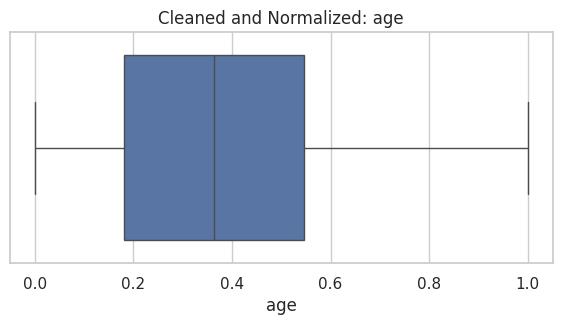

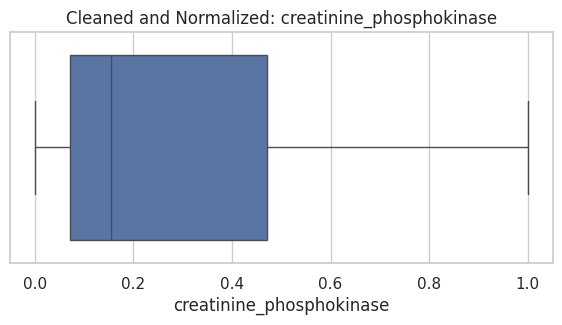

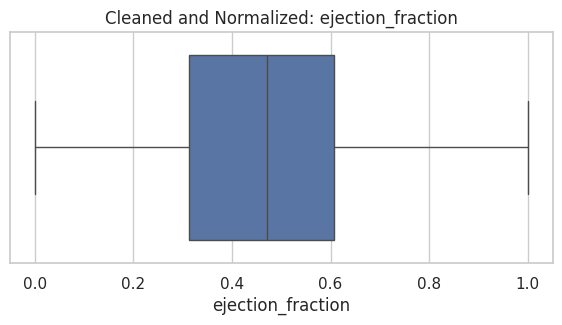

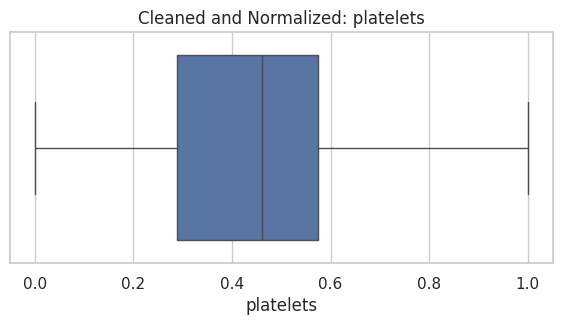

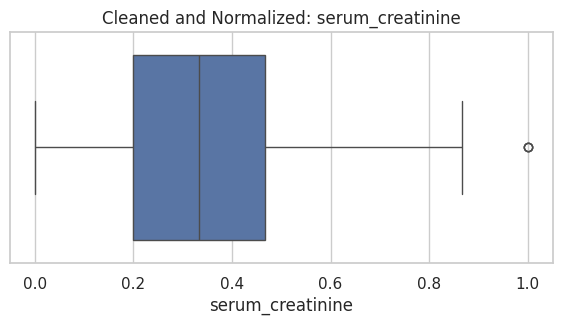

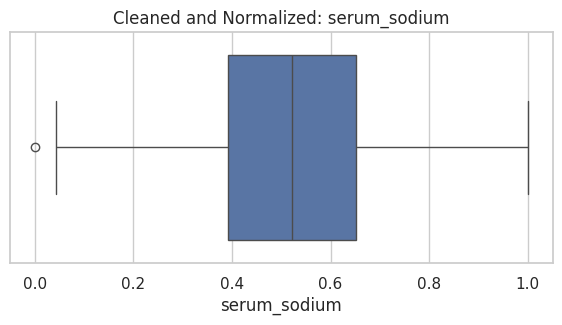

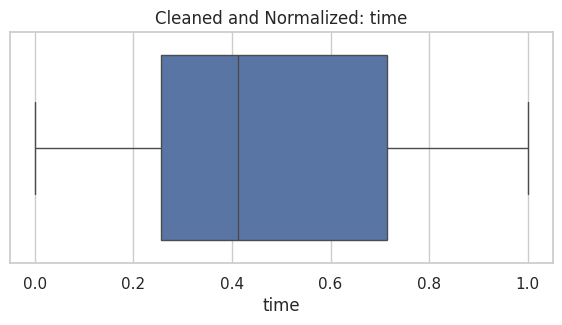

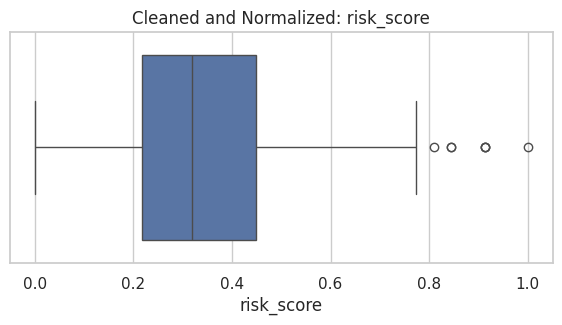

In [29]:
# Boxplots after cleaning

for feature in features_to_scale:
    plt.figure(figsize=(7, 3))

    sns.boxplot(
        x=df_no_outliers[feature]
    )

    plt.title(f"Cleaned and Normalized: {feature}")
    plt.xlabel(feature)

    plt.show()

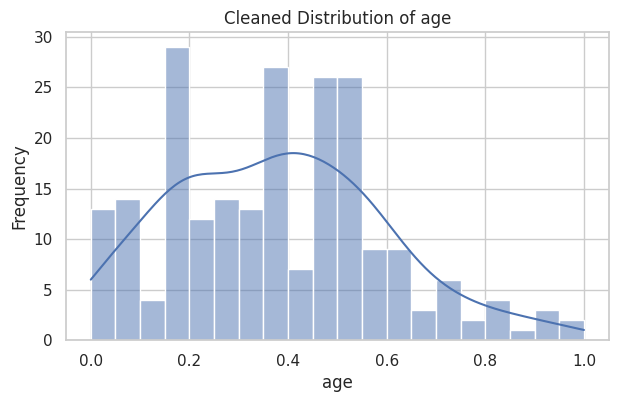

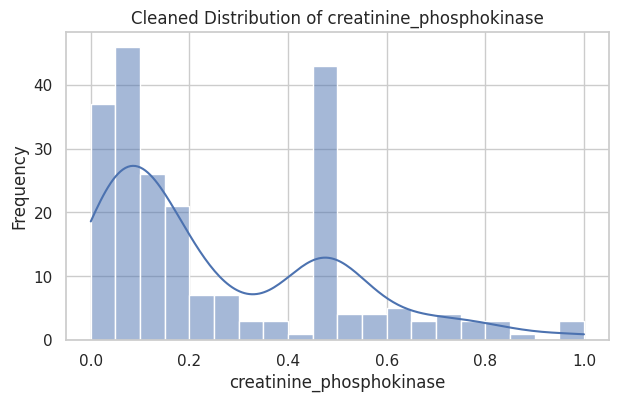

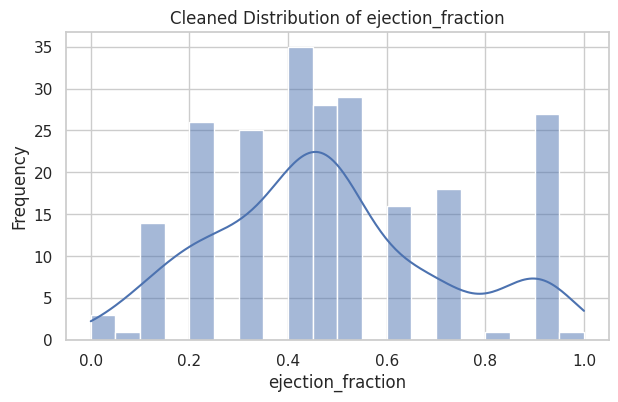

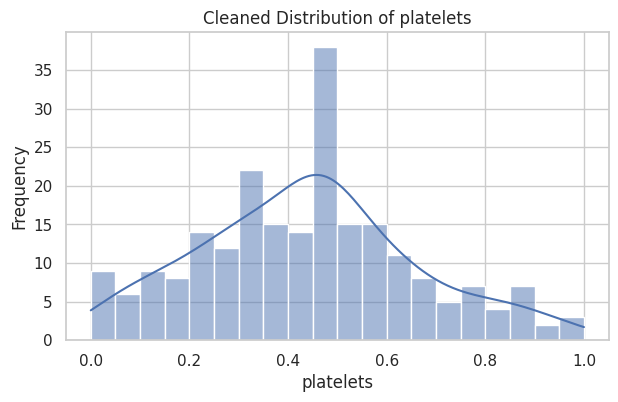

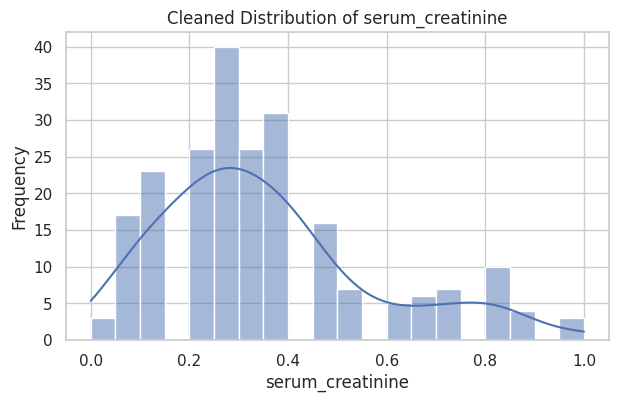

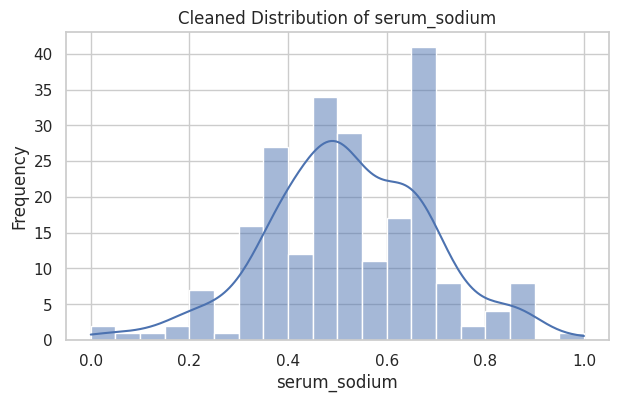

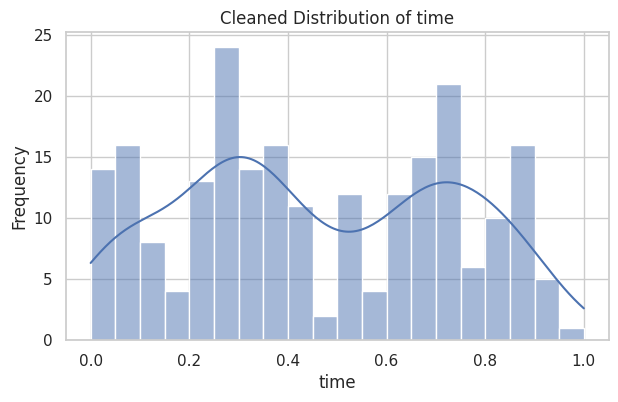

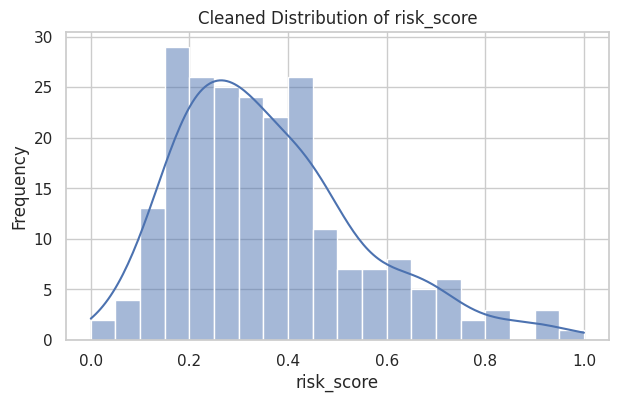

In [30]:
# Histograms after cleaning and normalization

for feature in features_to_scale:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        df_no_outliers[feature],
        kde=True,
        bins=20
    )

    plt.title(f"Cleaned Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

In [31]:
# Final missing-value validation

final_missing_values = df_no_outliers.isnull().sum()

print("Final missing values:")
print(final_missing_values)

print("\nTotal missing values:",
      final_missing_values.sum())

Final missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
age_group                   0
risk_score                  0
dtype: int64

Total missing values: 0


In [32]:
# Final dataset information

print("Final dataset shape:", df_no_outliers.shape)

print("\nFinal data types:")
print(df_no_outliers.dtypes)

print("\nFirst 5 rows of final cleaned dataset:")
display(df_no_outliers.head())

Final dataset shape: (224, 15)

Final data types:
age                          float64
anaemia                        int64
creatinine_phosphokinase     float64
diabetes                       int64
ejection_fraction            float64
high_blood_pressure            int64
platelets                    float64
serum_creatinine             float64
serum_sodium                 float64
sex                            int64
smoking                        int64
time                         float64
DEATH_EVENT                    int64
age_group                   category
risk_score                   float64
dtype: object

First 5 rows of final cleaned dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,age_group,risk_score
0,0.636,0,0.471,0,0.118,1,0.469,0.867,0.217,1,0,0.000,1,>60,0.311
2,0.455,0,0.099,0,0.118,0,0.131,0.467,0.174,1,1,0.011,1,>60,0.171
3,0.182,1,0.069,0,0.118,0,0.289,0.867,0.522,1,0,0.011,1,40-60,0.311
5,0.909,1,0.015,0,0.510,1,0.269,1.000,0.304,1,1,0.014,1,>60,0.844
6,0.636,1,0.184,0,0.020,0,0.016,0.400,0.522,1,0,0.021,1,>60,0.079


# Conclusion

The Heart Failure Clinical Records dataset was successfully acquired and analyzed.

The following preprocessing and data-cleaning operations were performed:

1. The dataset was downloaded and loaded into a Pandas DataFrame.
2. Dataset structure, data types and missing values were inspected.
3. Missing values were visualized using a Seaborn heatmap.
4. Numerical feature distributions were analyzed using histograms and boxplots.
5. Missing numerical and categorical values were handled conditionally using median and mode imputation.
6. Potential outliers were identified and removed using the IQR method.
7. Clinical inconsistencies such as negative age values were checked and corrected.
8. An `age_group` feature was created using the required age intervals.
9. A normalized engineered `risk_score` was created using ejection fraction and serum creatinine.
10. Binary categorical variables were verified and represented using 0/1 encoding.
11. Numerical features were normalized to the 0–1 range using MinMaxScaler.
12. Summary statistics were calculated before and after cleaning.
13. Cleaned distributions were visualized again to validate preprocessing.
14. The final dataset was checked to confirm that no missing values remained.

The final dataset is now in a cleaner and more model-ready format.